**Nome:** RICARDO FERNANDES DE ALMEIDA<br>
**Turma:** 2025.2<br>
**Especialização Cesar - Engenharia e Análise de DADOS**  
**Disciplina: RNA e Deep Learning**<br>
**Atividade Aula 2.7 - Vale o Dobro


# Regressão Linear com PyTorch - Dataset House Prices

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction?select=kc_house_data.csv).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [11]:
!pwd

/content


In [15]:
#!/bin/bash
!curl -L -o /content/housesalesprediction.zip "https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  2233k      0 --:--:-- --:--:-- --:--:--  129M


In [16]:
!unzip /content/housesalesprediction.zip

Archive:  /content/housesalesprediction.zip
  inflating: kc_house_data.csv       


In [17]:
# Load the dataset
df = pd.read_csv('/content/kc_house_data.csv')


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [21]:
df = df.drop(['id','date'],axis=1)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [25]:
Y = df['price'].values #vetor linha

In [33]:
y= df['price'].values.reshape(-1,1) #vetor coluna

In [34]:
y

array([[221900.],
       [538000.],
       [180000.],
       ...,
       [402101.],
       [400000.],
       [325000.]])

In [35]:
y.shape

(21613, 1)

In [30]:
X =  df.drop(['price'],axis =1).values

In [31]:
X

array([[ 3.00000e+00,  1.00000e+00,  1.18000e+03, ..., -1.22257e+02,
         1.34000e+03,  5.65000e+03],
       [ 3.00000e+00,  2.25000e+00,  2.57000e+03, ..., -1.22319e+02,
         1.69000e+03,  7.63900e+03],
       [ 2.00000e+00,  1.00000e+00,  7.70000e+02, ..., -1.22233e+02,
         2.72000e+03,  8.06200e+03],
       ...,
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ..., -1.22299e+02,
         1.02000e+03,  2.00700e+03],
       [ 3.00000e+00,  2.50000e+00,  1.60000e+03, ..., -1.22069e+02,
         1.41000e+03,  1.28700e+03],
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ..., -1.22299e+02,
         1.02000e+03,  1.35700e+03]])

In [32]:
X.shape

(21613, 18)

### Normalização dos dados

In [36]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [37]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 18])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 18])
y_val_tensor shape: torch.Size([6484, 1])


In [38]:
X.shape[1]

18

## Criação do modelo da rede

In [80]:
model = torch.nn.Linear(18, 1)

### Verificando a inicialização dos parâmetros

In [40]:
model.weight.data

tensor([[-0.2220, -0.0462, -0.1132, -0.0629, -0.2082,  0.0946, -0.2113, -0.0150,
          0.0819, -0.0794,  0.1337,  0.0297,  0.1296,  0.1512, -0.1041,  0.0857,
         -0.1020,  0.0739]])

### Testando o predict da rede

In [41]:
model(torch.ones(5,18))

tensor([[-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072]], grad_fn=<AddmmBackward0>)

In [42]:
model(X_train_tensor[:3])

tensor([[-0.8767],
        [ 0.1813],
        [-0.6099]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [81]:
criterion = nn.MSELoss()
#optimizer = optim.SGD(model.parameters(), lr=0.3)
#optimizer = optim.SGD(model.parameters(), lr=0.001)
#optimizer = optim.SGD(model.parameters(), lr=0.01)
#optimizer = optim.SGD(model.parameters(), lr=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.01)

#num_epochs = 220

num_epochs = 400

### Laço de treinamento

In [72]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [73]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [82]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/400], Train Loss: 0.898893, Val Loss: 0.934484
Epoch[4/400], Train Loss: 0.824955, Val Loss: 0.859079
Epoch[6/400], Train Loss: 0.762423, Val Loss: 0.795222
Epoch[8/400], Train Loss: 0.709175, Val Loss: 0.740802
Epoch[10/400], Train Loss: 0.663568, Val Loss: 0.694170
Epoch[12/400], Train Loss: 0.624309, Val Loss: 0.654020
Epoch[14/400], Train Loss: 0.590365, Val Loss: 0.619304
Epoch[16/400], Train Loss: 0.560902, Val Loss: 0.589172
Epoch[18/400], Train Loss: 0.535235, Val Loss: 0.562926
Epoch[20/400], Train Loss: 0.512801, Val Loss: 0.539990
Epoch[22/400], Train Loss: 0.493130, Val Loss: 0.519884
Epoch[24/400], Train Loss: 0.475830, Val Loss: 0.502206
Epoch[26/400], Train Loss: 0.460570, Val Loss: 0.486618
Epoch[28/400], Train Loss: 0.447070, Val Loss: 0.472833
Epoch[30/400], Train Loss: 0.435093, Val Loss: 0.460609
Epoch[32/400], Train Loss: 0.424437, Val Loss: 0.449740
Epoch[34/400], Train Loss: 0.414928, Val Loss: 0.440047
Epoch[36/400], Train Loss: 0.406420, Val Loss: 0.431

## Avaliação

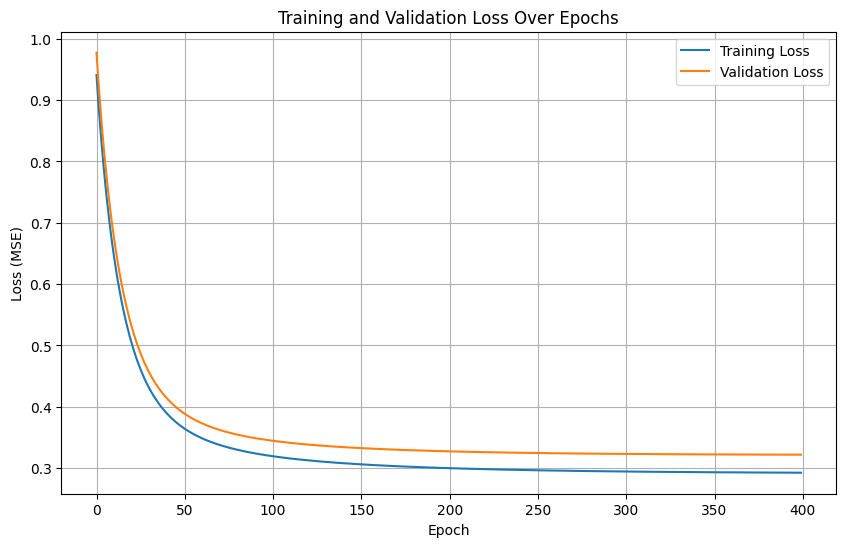

In [83]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()